# Checking the data in Sweetman et al. 2024

In [17]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pingouin import madmedianrule
import seaborn as sns

from segmentaks import print_correlation, matplotlib_has_latex

# Data files as available from https://www.nature.com/articles/s41561-024-01480-8 and the linked dryad repository
AREA_DATA_FILE = 'data/sweetman_2024/Surface_area_of_nodules_versus_total_oxygen_change.xlsx' #Dryad
OPTODE_DATA_FILE = 'data/sweetman_2024/41561_2024_1480_MOESM2_ESM.xlsx'

# Ensure output directories are present
Path('plots').mkdir(exist_ok=True)

PLOTS_FOR_PAPER = True

For publication quality plots - LaTeX needs to be available. If running the following cell causes errors, then make sure LaTeX is available or skip this cell.

In [18]:
import scienceplots
plt.style.use(['science','nature'])

if not matplotlib_has_latex():
    raise RuntimeError("Matplotlb requires access to Latex to create publication quality plots.")

In [19]:
df = pd.read_excel(AREA_DATA_FILE)
df.style

,Chamber ID,Total O2 change (micromol chamber-1),Number of nodules chamber-1,Total area of nodules (cm2),Average surface area of nodules (cm2)
0,AKS268-Ch.3,1007.678547,50,271.103000,5.422060
1,AKS273-Ch.3,1544.781223,23,216.174000,9.398870
2,AKS276-Ch.3,670.874245,49,248.900000,5.079592
3,AKS282-Ch.3,245.534137,66,270.998000,4.106030
4,AKS286-Ch.3,328.577357,52,261.958000,5.037654
5,AKS328-Ch.2,257.383188,76,334.892000,4.406474
6,AKS328- Ch.3,683.081476,78,281.246000,3.605718
7,AKS329- Ch.2,773.521061,50,300.220000,6.004400
8,AKS334-Ch.2,1710.164342,55,317.086000,5.765200
9,AKS334-Ch.3,651.958011,70,288.659000,4.123700


In [20]:

spear_o2umol_coverage = stats.spearmanr(a=df['Total O2 change (micromol chamber-1)'], b=df['Total area of nodules (cm2)'])
spear_o2umol_avg_area = stats.spearmanr(a=df['Total O2 change (micromol chamber-1)'], b=df['Average surface area of nodules (cm2)'])
spear_o2umol_number_nodules = stats.spearmanr(a=df['Total O2 change (micromol chamber-1)'], b=df['Number of nodules chamber-1'])
kendall_o2umol_coverage = stats.kendalltau(x=df['Total O2 change (micromol chamber-1)'], y=df['Total area of nodules (cm2)'])
kendall_o2umol_avg_area = stats.kendalltau(x=df['Total O2 change (micromol chamber-1)'], y=df['Average surface area of nodules (cm2)'])

print(f"Spearman correlation between Total O2 change and Total area of nodules: {spear_o2umol_coverage[0]:.3f} (p={spear_o2umol_coverage[1]:.3f})")
print(f"Spearman correlation between Total O2 change and Average surface area of nodules: {spear_o2umol_avg_area[0]:.3f} (p={spear_o2umol_avg_area[1]:.3f})")
print(f"Spearman correlation between Total O2 change and Number of nodules: {spear_o2umol_number_nodules[0]:.3f} (p={spear_o2umol_number_nodules[1]:.3f})")
print(f"Kendall correlation between Total O2 change and Total area of nodules: {kendall_o2umol_coverage[0]:.3f} (p={kendall_o2umol_coverage[1]:.3f})")
print(f"Kendall correlation between Total O2 change and Average surface area of nodules: {kendall_o2umol_avg_area[0]:.3f} (p={kendall_o2umol_avg_area[1]:.3f})")

Spearman correlation between Total O2 change and Total area of nodules: -0.136 (p=0.689)
Spearman correlation between Total O2 change and Average surface area of nodules: 0.664 (p=0.026)
Spearman correlation between Total O2 change and Number of nodules: -0.433 (p=0.184)
Kendall correlation between Total O2 change and Total area of nodules: -0.127 (p=0.648)
Kendall correlation between Total O2 change and Average surface area of nodules: 0.491 (p=0.041)


Text(0.5, 1.0, 'Total O2 change vs Average surface area of nodules')

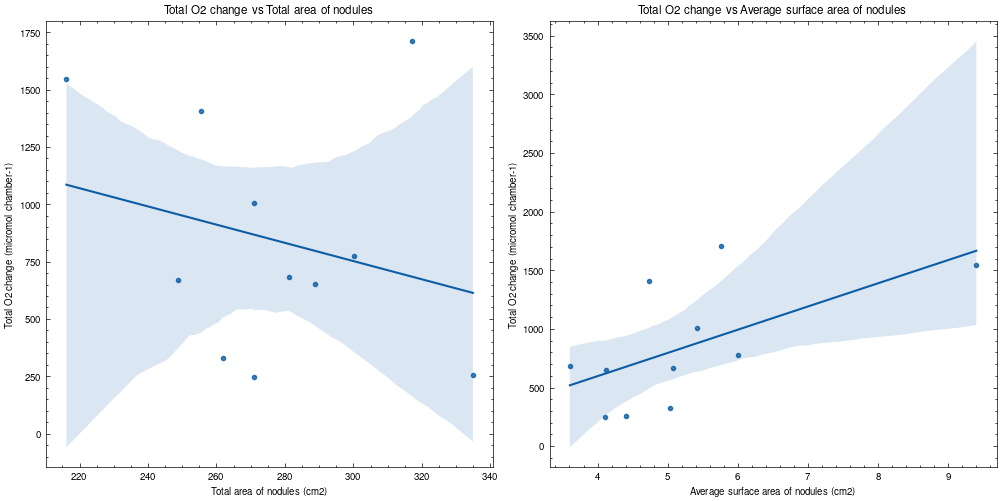

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), layout='constrained')
sns.regplot(x='Total area of nodules (cm2)', y='Total O2 change (micromol chamber-1)', data=df, ax=ax1)
ax1.set_title('Total O2 change vs Total area of nodules')
sns.regplot(x='Average surface area of nodules (cm2)', y='Total O2 change (micromol chamber-1)', data=df, ax=ax2)
ax2.set_title('Total O2 change vs Average surface area of nodules')

### Correlation exploration

Although Spearman's correlation is significant (p=0.026), there is a univariate outlier, and shepherd's correlation removes two bivariate outliers. The result is p=0.2054

In [22]:
x = df['Average surface area of nodules (cm2)']
y = df['Total O2 change (micromol chamber-1)']

print(madmedianrule(x)) # One True value indicates that there is at least a univariate outlier - Pearson's should not be used.
print(madmedianrule(y))
print_correlation(x, y, method='spearman') # Spearman's is signigicant
print_correlation(x, y, method='bicor')
print_correlation(x, y, method='percbend') # Almost significant, but the confidence interval includes zero.
print_correlation(x, y, method='skipped') # skipped is signigicant - doesn't remove any outliers so the result is the same as Spearman's.
print_correlation(x, y, method='shepherd') # Two bivariate outliers are detected.

[False  True False False False False False False False False False]
[False False False False False False False False False False False]
Spearman r = 0.6636  |  p = 0.0260  |  95% CI = [0.1100, 0.9000] | outliers: N/A
Bicor r = 0.5667  |  p = 0.0691  |  95% CI = [-0.0500, 0.8700] | outliers: N/A
Percbend r = 0.5992  |  p = 0.0514  |  95% CI = [-0.0000, 0.8800] | outliers: N/A
Skipped r = 0.6636  |  p = 0.0260  |  95% CI = [0.1100, 0.9000] | outliers: 0
Shepherd r = 0.4667  |  p = 0.2054  |  95% CI = [-0.2900, 0.8600] | outliers: 2


c:\Users\AlexanderWebber\Documents\Python\SegmentAKS\.venv\Lib\site-packages\pingouin\correlation.py:134: UserWarning: The skipped correlation relies on the Minimum Covariance Determinant algorithm, which gives slightly different results in Python (scikit-learn) than in the original Matlab library (LIBRA). As such, the skipped correlation may be different from the Matlab robust correlation toolbox (see issue 164 on Pingouin's GitHub). Make sure to double check your results or use another robust correlation method.
  warnings.warn(


Correlation if the one univariate outlier is excluded

In [23]:
x = np.asarray(df['Average surface area of nodules (cm2)'])
y = np.asarray(df['Total O2 change (micromol chamber-1)'])

valid = np.asarray(madmedianrule(x))
x = x[~valid]
y = y[~valid]

print_correlation(x, y, method='spearman')

Spearman r = 0.5758  |  p = 0.0816  |  95% CI = [-0.0800, 0.8800] | outliers: N/A


Optode data for the omitted chambers

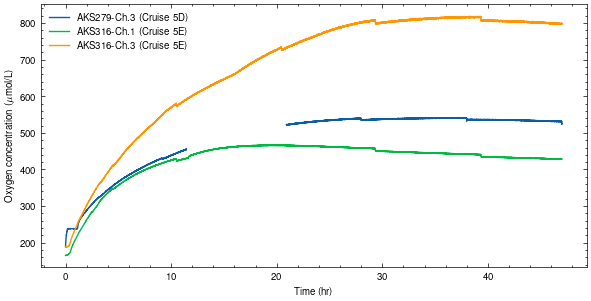

In [24]:
df_optode_5D = pd.read_excel(OPTODE_DATA_FILE, sheet_name='Cruise 5D', header=1)
df_optode_5E = pd.read_excel(OPTODE_DATA_FILE, sheet_name='Cruise 5E', header=1)

fig, ax = plt.subplots(figsize=(5.9, 3), layout='constrained')

ax.plot(df_optode_5D['Time (hr)'], df_optode_5D['AKS279-Ch.3 '], label='AKS279-Ch.3 (Cruise 5D)')
ax.plot(df_optode_5E['Time (hr)'], df_optode_5E['AKS316-Ch.1'], label='AKS316-Ch.1 (Cruise 5E)')
ax.plot(df_optode_5E['Time (hr)'], df_optode_5E['AKS316-Ch.3'], label='AKS316-Ch.3 (Cruise 5E)')
ax.legend()

ax.set_xlabel('Time (hr)')
ax.set_ylabel('Oxygen concentration ($\\mu$mol/L)')

if PLOTS_FOR_PAPER:
    fig.savefig('plots/Figure_2.tif', dpi=600)